# 01 · Exploratory data analysis: Kestrel service-request routing

**Question this notebook answers:** what is in the data pack, how far can we trust it, and what should the model learn?

Read alongside `PS_T2.pdf`, `Data/ops-policy.pdf` and `Data/email-thread.txt`. Section numbers like *§3* refer to the ops policy.

> **Data handling (policy §10).** Customer data must not be published. Every request text shown in this notebook has order and registration numbers masked (`[id]`), and only short template-like examples are shown. Clear the outputs before pushing anywhere public if in doubt.

In [1]:
import sys, re
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # Solution/ on the path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kestrel_router import data as D, features as F
from kestrel_router.plotting import use_style, heatmap, BLUE, ORANGE, AQUA, GREY

use_style()
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 160)

raw_train = pd.read_csv(D.DATA_DIR / "train.csv")
raw_test = pd.read_csv(D.DATA_DIR / "test_unlabelled.csv")
raw_res = pd.read_csv(D.DATA_DIR / "resolution_log.csv")
teams = pd.read_csv(D.DATA_DIR / "teams.csv")
sample = pd.read_csv(D.DATA_DIR / "sample_submission.csv")
show = lambda s: s.map(D.mask_ids)   # mask ids in anything we print

## 1 · The files at a glance

In [2]:
def profile(name, df, date_col=None):
    r = {"file": name, "rows": len(df), "cols": df.shape[1],
         "nulls": int(df.isna().sum().sum()), "dup ids": int(df["request_id"].duplicated().sum()) if "request_id" in df else None}
    if date_col:
        r["from"], r["to"] = df[date_col].min(), df[date_col].max()
    return r

pd.DataFrame([
    profile("train.csv", raw_train, "created_at_ist"),
    profile("test_unlabelled.csv", raw_test, "created_at_ist"),
    profile("resolution_log.csv", raw_res, "resolved_at"),
    profile("sample_submission.csv", sample),
])

,file,rows,cols,nulls,dup ids,from,to
0,train.csv,10822,8,0,0,2025-04-01 00:31,2026-06-30 23:33
1,test_unlabelled.csv,2178,7,0,0,2026-07-01 00:31,2026-09-30 23:00
2,resolution_log.csv,10822,5,0,0,2025-03-31 22:41,2026-07-02 16:16
3,sample_submission.csv,2178,2,0,0,NaN,NaN


In [3]:
teams

,team,renamed_to,handles
0,Installations,Installs & Demo (from 15 Jan 2026),"New-product installation, demo and wall-mounting visits."
1,Repairs,NaN,"Product faults, breakdowns, error codes, noise, leaks - anything that needs a technician to fix."
2,Consumables,Filters & Consumables (from 15 Jan 2026),"Filters, candles, membranes, jars, brushes, blades, AMC kits - selling and fitting spares. Not faults."
3,Billing,NaN,"Invoices, GST, double charges, refunds of payments, EMI conversion, coupons. Only when the problem IS the ..."
4,Returns & Replacement,NaN,"Damaged, wrong or incomplete deliveries; returns and exchanges within the return window."
5,Warranty Claims,NaN,"Warranty and Kestrel Shield registration, coverage questions, claim status."
6,Product Advice,NaN,Pre- and post-purchase usage questions. No fault reported.


In [4]:
print("sample_submission teams:", sample["team"].value_counts().to_dict(), " <- format example only")
print("test ids == sample ids:", set(sample.request_id) == set(raw_test.request_id))
print("train ids == resolution ids:", set(raw_train.request_id) == set(raw_res.request_id))

sample_submission teams: {'Repairs': 2178}  <- format example only
test ids == sample ids: True
train ids == resolution ids: True


In [5]:
cmp = pd.concat({c: pd.concat([raw_train[c].value_counts(normalize=True).rename("train"),
                               raw_test[c].value_counts(normalize=True).rename("test")], axis=1)
                 for c in ["channel", "product_family", "warranty_status", "source"]}).round(3)
cmp

train   test
channel         chat               0.308  0.291
                whatsapp           0.298  0.303
                ivr                0.290  0.303
                email              0.103  0.103
product_family  Water Purifier     0.202  0.209
                Air Fryer          0.178  0.183
                Mixer Grinder      0.149  0.147
                Induction Cooktop  0.136  0.131
                Room Heater        0.120  0.121
                Ceiling Fan        0.119  0.119
                Robot Vacuum       0.096  0.090
warranty_status in_warranty        0.544  0.547
                out_of_warranty    0.252  0.255
                shield             0.204  0.198
source          crm                0.601  1.000
                legacy_zoho        0.399    NaN

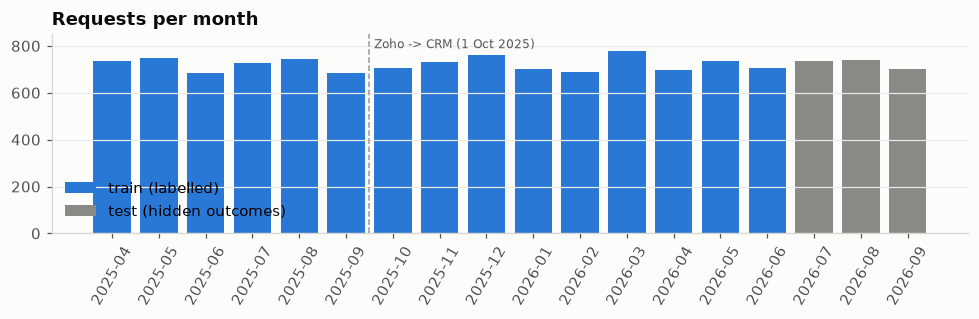

train: 721 requests/month · test: 726 requests/month


In [6]:
fig, ax = plt.subplots(figsize=(9, 3))
m_tr = raw_train.groupby(raw_train.created_at_ist.str[:7]).size()
m_te = raw_test.groupby(raw_test.created_at_ist.str[:7]).size()
ax.bar(m_tr.index, m_tr.values, color=BLUE, label="train (labelled)")
ax.bar(m_te.index, m_te.values, color=GREY, label="test (hidden outcomes)")
ax.axvline(5.5, color="#999", ls="--", lw=1); ax.text(5.6, 790, "Zoho -> CRM (1 Oct 2025)", fontsize=8, color="#555")
ax.set_ylim(0, 850); ax.set_title("Requests per month", loc="left"); ax.tick_params(axis="x", rotation=60)
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()
print(f"train: {len(raw_train)/15:.0f} requests/month · test: {len(raw_test)/3:.0f} requests/month")

**Notes**
- 15 months of training data (Apr 2025 – Jun 2026) + 3 months of test (Jul – Sep 2026) = the "eighteen months" in Ritu's email.
- ~720 requests a month, steady. The PS form says "about 700 orders a month"; close enough, we use the measured figure for savings.
- Test is **100% CRM**; 40% of training rows are legacy Zoho. Channel / product / warranty mixes are the same in train and test.
- No nulls, no duplicate ids, every train row has exactly one resolution-log row.

## 2 · What is `team_label`? (the most important finding)

Ritu calls the labels "ground truth". Tanmay's email says *"team_label is the queue the bot put each request in when it came in. The resolution log has where each one actually ended up."*

In [7]:
df = D.load_train()   # joins resolution log, merges renamed teams, cleans text
print(f"team_label == first_team : {(df.team_label == df.first_team).mean():.1%}")
print(f"team_label == final_team : {(df.team_label == df.final_team).mean():.1%}   <- how often the bot was right")

team_label == first_team : 100.0%
team_label == final_team : 77.2%   <- how often the bot was right


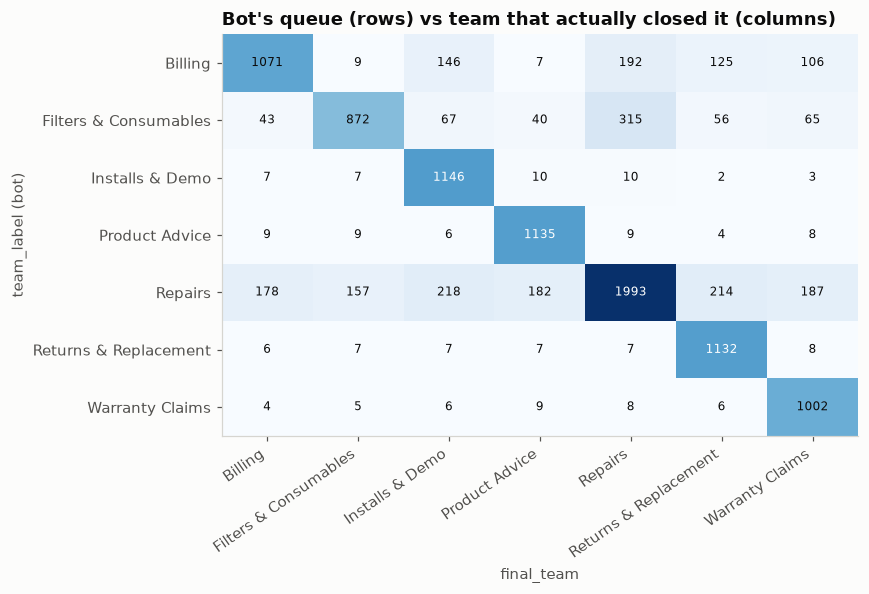

In [8]:
ct = pd.crosstab(df.team_label, df.final_team)
fig, ax = plt.subplots(figsize=(8, 5.5))
heatmap(ax, ct, "Bot's queue (rows) vs team that actually closed it (columns)")
ax.set_xlabel("final_team"); ax.set_ylabel("team_label (bot)")
plt.tight_layout(); plt.show()

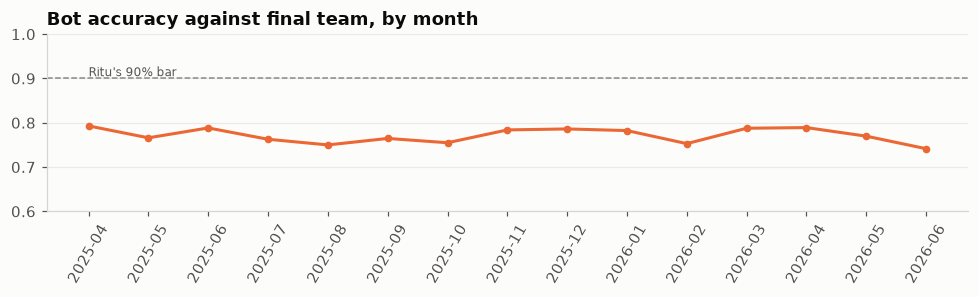

In [9]:
monthly = df.groupby(df.created_at.dt.to_period("M")).apply(lambda g: (g.team_label == g.final_team).mean())
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(monthly.index.astype(str), monthly.values, color=ORANGE, marker="o", ms=4)
ax.set_ylim(0.6, 1.0); ax.axhline(0.9, color=GREY, ls="--", lw=1); ax.text(0, 0.905, "Ritu's 90% bar", fontsize=8, color="#555")
ax.set_title("Bot accuracy against final team, by month", loc="left"); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

**Finding.** `team_label` *is* `first_team` (100%): it is the bot's guess, not the outcome. The bot is right **77.2%** of the time, steady every month.

**Decision.** The target is **`final_team`**. A model trained to "match the labels at 90%" would be a copy of a router that is wrong one time in four. The hidden test is scored against *"outcomes you do not have"*, which is the final team.

## 3 · Team renames (§5)

In [10]:
r = pd.read_csv(D.DATA_DIR / "resolution_log.csv").merge(raw_train[["request_id", "created_at_ist"]])
r["month"] = r.created_at_ist.str[:7]
x = r[r.final_team.isin(["Installations", "Installs & Demo", "Consumables", "Filters & Consumables"])]
x.groupby(["month", "final_team"]).size().unstack(fill_value=0).loc["2025-11":"2026-03"]

final_team,Consumables,Filters & Consumables,Installations,Installs & Demo
month,,,,
2025-11,69,0,102,0
2025-12,69,0,126,0
2026-01,38,42,37,61
2026-02,0,72,0,97
2026-03,0,77,0,111


In [11]:
cut = pd.Timestamp("2026-01-15")
t = pd.to_datetime(raw_train.created_at_ist)
for col, s in [("team_label", raw_train.team_label), ("final_team", r.set_index("request_id").loc[raw_train.request_id, "final_team"].values)]:
    s = pd.Series(s)
    print(f"{col}: old names after 15 Jan = {(s[t.values >= cut].isin(D.RENAMES)).sum()}, "
          f"new names before = {(s[t.values < cut].isin(D.RENAMES.values())).sum()}")

team_label: old names after 15 Jan = 0, new names before = 0
final_team: old names after 15 Jan = 0, new names before = 0


**Finding.** A clean cut on 15 Jan 2026, no overlap. Responsibilities did not change.

**Decision.** Merge everywhere: Installations → **Installs & Demo**, Consumables → **Filters & Consumables**. Seven classes, and we predict the current names (every test row is after the rename).

## 4 · Transfers and two kinds of suspicious rows

Policy §3: *"Agents transfer requests that reached the wrong team. The team that closes the request is recorded as the final team."* So `first_team != final_team` should always mean at least one transfer.

In [12]:
pd.crosstab(np.where(df.first_team == df.final_team, "first == final", "first != final"), df.transfers,
            margins=True).rename_axis(index="", columns="transfers")

transfers,0,1,2,All
,,,,
first != final,126,1141,1204,2471
first == final,8000,349,2,8351
All,8126,1490,1206,10822


Two cells should be empty and are not:

| Pattern | Rows | What it means |
|---|---|---|
| **first ≠ final, 0 transfers** ("impossible") | **126** | The request changed team without a transfer. Per §3 this can't happen; the final team or the transfer count is wrong. |
| **first = final, ≥1 transfer** ("ping-pong") | **351** | Moved out and came back to the team the bot chose (A → B → A). Plausible: the bot was right and an agent wrongly transferred it. |

In [13]:
imp = df[df.impossible]
print("impossible rows:", len(imp), f"({len(imp)/len(df):.1%})")
print("by source:", imp.source.value_counts().to_dict())
show_cols = ["request_text", "product_family", "first_team", "final_team", "transfers"]
imp.assign(request_text=show(imp.request_text))[show_cols].head(10)

impossible rows: 126 (1.2%)
by source: {'crm': 69, 'legacy_zoho': 57}


,request_text,product_family,first_team,final_team,transfers
136,need warranty certificate mixer grinder order [id],Mixer Grinder,Warranty Claims,Repairs,0
323,difference between lite and pro room heater kindly resolve,Room Heater,Product Advice,Warranty Claims,0
350,pls help - induction cooktop leaking water from bottom,Induction Cooktop,Repairs,Product Advice,0
364,"namaste, installer did not turn up for robot vacuum kindly resolve",Robot Vacuum,Installs & Demo,Repairs,0
496,extend warranty for mixer grinder asap,Mixer Grinder,Warranty Claims,Repairs,0
502,"hi, return pickup for water purifier not done",Water Purifier,Returns & Replacement,Warranty Claims,0
571,"hello team, room heater leaking water from bottom order [id]",Room Heater,Repairs,Returns & Replacement,0
632,"hi, room heater making loud noise",Room Heater,Repairs,Product Advice,0
634,"is robot vacuum safe for kids, recipe booklet for robot vacuum order [id]",Robot Vacuum,Product Advice,Warranty Claims,0
702,sir induction cooktop missing parts in box,Induction Cooktop,Returns & Replacement,Installs & Demo,0


Most "impossible" rows have a final team that contradicts the text (a warranty certificate closed by Repairs, a "lite vs pro" question closed by Warranty Claims). The first team (the bot's guess) is usually the sensible one. These look like **bad final labels**.

In [14]:
pp = df[df.pingpong]
print("ping-pong rows:", len(pp), f"({len(pp)/len(df):.1%})", " by transfers:", pp.transfers.value_counts().to_dict())
print("by source:", pp.source.value_counts().to_dict())
pp.assign(request_text=show(pp.request_text))[show_cols].head(10)

ping-pong rows: 351 (3.2%)  by transfers: {1: 349, 2: 2}
by source: {'crm': 200, 'legacy_zoho': 151}


,request_text,product_family,first_team,final_team,transfers
4,"hi, display of air fryer gone blank thanks",Air Fryer,Repairs,Repairs,1
21,"hi, invoice not received for induction cooktop",Induction Cooktop,Billing,Billing,1
42,"hello team, shield plan renewal for vacuum",Mixer Grinder,Warranty Claims,Warranty Claims,1
71,need warranty certificate purifier pls call back,Water Purifier,Warranty Claims,Warranty Claims,1
125,spare blade set for induction cooktop available?,Induction Cooktop,Filters & Consumables,Filters & Consumables,1
135,"hi, filter change reminder for product asap Ã¢â‚¬Â¦",Mixer Grinder,Filters & Consumables,Filters & Consumables,1
192,which induction cooktop is right for 4 people thanks,Induction Cooktop,Product Advice,Product Advice,1
230,"hi, motor of mixer grinder burnt smell, want to return the mixer grinder thanks",Mixer Grinder,Returns & Replacement,Returns & Replacement,1
236,"hello team, consumable pack for ceiling fan price pls call back",Ceiling Fan,Filters & Consumables,Filters & Consumables,1
245,"good morning, need warranty certificate air fryer thanks",Air Fryer,Warranty Claims,Warranty Claims,1


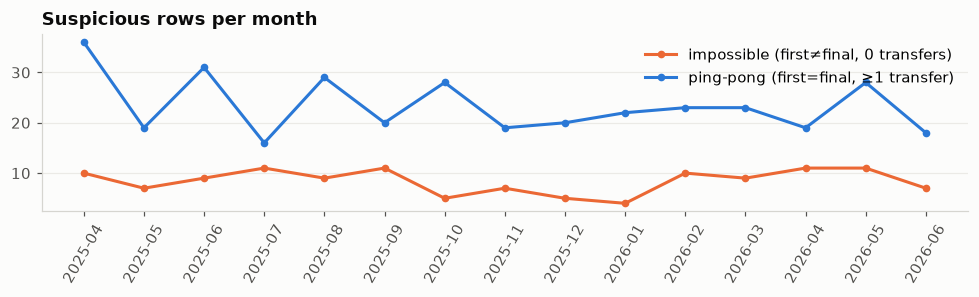

In [15]:
fig, ax = plt.subplots(figsize=(9, 2.8))
mm = df.groupby(df.created_at.dt.to_period("M"))[["impossible", "pingpong"]].sum()
ax.plot(mm.index.astype(str), mm.impossible, color=ORANGE, marker="o", ms=4, label="impossible (first≠final, 0 transfers)")
ax.plot(mm.index.astype(str), mm.pingpong, color=BLUE, marker="o", ms=4, label="ping-pong (first=final, ≥1 transfer)")
ax.set_title("Suspicious rows per month", loc="left"); ax.tick_params(axis="x", rotation=60); ax.legend()
plt.tight_layout(); plt.show()

**Findings**
- Both patterns appear every month, in both Zoho and CRM data, so they are not a migration artefact. The hidden test period will contain them too.
- Ping-pong rows have texts that match their (final = first) team: the final label looks right, the transfers were agent mistakes. Ping-pong is still a real cost: ~350 transfers × Rs 305 ≈ Rs 1.1 lakh of handling time over 15 months, spent going round in a circle.

**Decisions**
- **Drop the 126 impossible rows from training only** (approach B1). Keep them in every evaluation set, because the hidden test will have them and our score forecast must be honest.
- **Keep the ping-pong rows**: their final label is credible.
- Rows with 2 transfers where first ≠ final are normal (wrong → wrong → right).

## 5 · Where the bot goes wrong (and why the policy matters)

In [16]:
out = (df.assign(ok=df.final_team == df.team_label).groupby("team_label")
       .agg(requests=("ok", "size"), stayed=("ok", "mean")).sort_values("stayed"))
out["stayed"] = out.stayed.map("{:.0%}".format); out

,requests,stayed
team_label,,
Filters & Consumables,1458,60%
Repairs,3129,64%
Billing,1656,65%
Product Advice,1180,96%
Warranty Claims,1040,96%
Returns & Replacement,1174,96%
Installs & Demo,1185,97%


In [17]:
flags = df.text_clean.map(F.intent_flags).apply(pd.Series)
df["paid_not_payment"] = flags.paid_mention & ~flags.payment_problem
b = df[df.team_label == "Billing"]
print("Requests the bot sent to Billing:", len(b))
print("  ...that only *mention* paying (no payment problem):", int(b.paid_not_payment.sum()),
      "-> of which closed by Billing:", int((b[b.paid_not_payment].final_team == "Billing").sum()))
print("\nWhere those 'I paid' requests really went:")
print(b[b.paid_not_payment].final_team.value_counts().to_string())

Requests the bot sent to Billing: 1656
  ...that only *mention* paying (no payment problem): 522 -> of which closed by Billing: 1

Where those 'I paid' requests really went:
final_team
Repairs                  181
Installs & Demo          131
Returns & Replacement    111
Warranty Claims           96
Product Advice             2
Billing                    1


**Policy §3 in action.** *"A customer mentioning that they have paid does not make it a billing request."* The bot ignores this rule: almost none of the "I paid for my installation" requests it sent to Billing were billing problems. This is Meenal's *"half my Billing queue some weeks"*.

Bot -> Filters & Consumables: 1458 | closed by Repairs: 315 | with a fault word in the text: 298


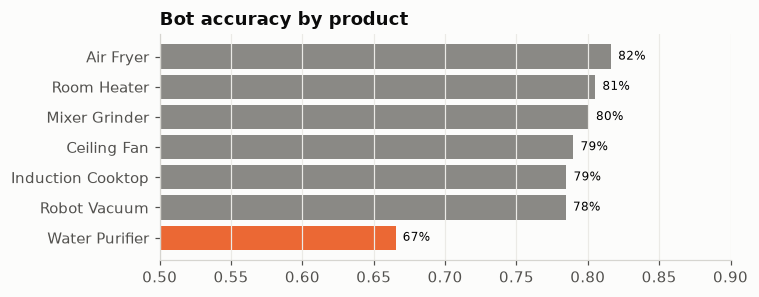

In [18]:
c = df[df.team_label == "Filters & Consumables"]
print("Bot -> Filters & Consumables:", len(c), "| closed by Repairs:", (c.final_team == "Repairs").sum(),
      "| with a fault word in the text:", int(c.text_clean.str.contains(F.INTENTS['fault']).sum()))
acc_p = df.groupby("product_family").apply(lambda g: (g.team_label == g.final_team).mean()).sort_values()
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(acc_p.index, acc_p.values, color=[ORANGE if p == "Water Purifier" else GREY for p in acc_p.index])
ax.set_xlim(0.5, 0.9); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
for i, v in enumerate(acc_p.values): ax.text(v + 0.005, i, f"{v:.0%}", va="center", fontsize=8)
ax.set_title("Bot accuracy by product", loc="left"); plt.tight_layout(); plt.show()

**Meenal's second complaint confirmed:** purifier breakdowns ("leaking", "error code") are sent to Consumables because purifiers also buy filters. teams.csv says Consumables is *"Not faults"*. Purifier is the bot's worst product.

## 6 · Request structure: vague requests and two-intent requests

The texts follow a pattern: optional greeting, one or two intents (comma-separated), optional filler (`pls call back`, `paid on upi`, an order number). Stripping greeting, filler and product name leaves the request's **shape**. Grouping by shape shows how predictable the final team is.

In [19]:
df["shape"] = df.text_clean.map(F.shape)
g = df.groupby("shape").final_team.agg(n="size", purity=lambda s: s.value_counts(normalize=True).iloc[0])
g = g[g.n >= 15].sort_values("purity")
g.head(14).style.format({"purity": "{:.0%}"})

,n,purity
shape,,
someone contact me about,178,19%
service request for,163,19%
complaint about,167,19%
please call back regarding,160,21%
issue with,151,21%
help,137,23%
not happy with,164,23%
query,147,24%
problem,153,25%


Ten shapes have ~20% purity (the final team is close to random), while every other common shape is above 95%. These are **vague requests**: Meenal's *"pile of 'please call me about my purifier' that nobody can route without asking"*.

vague share: train 14.5% · test 14.5%
bot accuracy: vague 21.2% · clear 86.7%


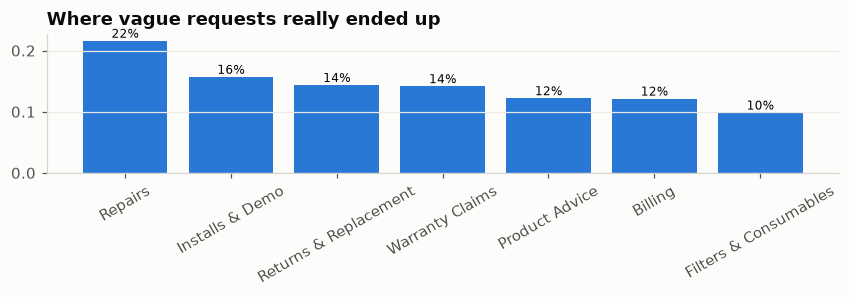

final_team       Billing  Filters & Consumables  Installs & Demo  Product Advice  Repairs  Returns & Replacement  Warranty Claims
warranty_status                                                                                                                  
in_warranty         0.12                   0.10             0.16            0.13     0.21                   0.14             0.14
out_of_warranty     0.14                   0.08             0.15            0.13     0.23                   0.15             0.11
shield              0.10                   0.12             0.15            0.10     0.20                   0.13             0.19


In [20]:
df["vague"] = df.text_clean.map(F.is_vague)
te = D.load_test(); te["vague"] = te.text_clean.map(F.is_vague)
print(f"vague share: train {df.vague.mean():.1%} · test {te.vague.mean():.1%}")
print(f"bot accuracy: vague {(df[df.vague].team_label == df[df.vague].final_team).mean():.1%} · "
      f"clear {(df[~df.vague].team_label == df[~df.vague].final_team).mean():.1%}")
fig, ax = plt.subplots(figsize=(8, 2.8))
v = df[df.vague].final_team.value_counts(normalize=True)
ax.bar(v.index, v.values, color=BLUE); ax.tick_params(axis="x", rotation=30)
for i, x in enumerate(v.values): ax.text(i, x + 0.005, f"{x:.0%}", ha="center", fontsize=8)
ax.set_title("Where vague requests really ended up", loc="left"); plt.tight_layout(); plt.show()
print(pd.crosstab(df[df.vague].warranty_status, df[df.vague].final_team, normalize="index").round(2))

**Finding.** ~15% of requests carry no routing information. Even the best guess (Repairs) is right only ~22% of the time; warranty status shifts the odds only a little. **No model can route these well; the right answer is to ask the customer one question** (approach C).

In [21]:
# Two-intent requests: which intent does the closing team follow?
single = g[(g.purity > 0.9)].index
team_of_shape = df[df["shape"].isin(single)].groupby("shape").final_team.agg(lambda s: s.value_counts().index[0])
def parts(t):
    return [F.shape(p) for p in F.strip_greeting(t).split(",") if p.strip()]
two = df[df.text_clean.map(lambda t: len(parts(t)) == 2)].copy()
two["t_first"] = two.text_clean.map(lambda t: team_of_shape.get(parts(t)[0]))
two["t_last"] = two.text_clean.map(lambda t: team_of_shape.get(parts(t)[1]))
two = two.dropna(subset=["t_first", "t_last"]); diff = two[two.t_first != two.t_last]
print(f"two-intent requests with two different teams: {len(diff)} ({len(diff)/len(df):.1%} of train)")
print(f"  closed by the FIRST intent's team: {(diff.final_team == diff.t_first).mean():.1%}")
print(f"  closed by the LAST intent's team:  {(diff.final_team == diff.t_last).mean():.1%}")
print(f"  bot right on these: {(diff.team_label == diff.final_team).mean():.1%}")
diff.assign(request_text=show(diff.request_text))[["request_text", "t_first", "t_last", "final_team"]].head(6)

two-intent requests with two different teams: 465 (4.3% of train)
  closed by the FIRST intent's team: 0.4%
  closed by the LAST intent's team:  99.1%
  bot right on these: 85.2%


,request_text,t_first,t_last,final_team
11,"urgent: ceiling fan making loud noise, power consumption of ceiling fan reg no [id]",Repairs,Product Advice,Product Advice
23,"power consumption of ceiling fan, ceiling fan making loud noise paid on upi very disappointed",Product Advice,Repairs,Repairs
24,"is room heater covered under shield plan, motor of room heater burnt smell thanks",Warranty Claims,Repairs,Repairs
83,"return pickup for water purifier not done, need warranty certificate water purifier thanks Ã¢â‚¬Â¦",Returns & Replacement,Warranty Claims,Warranty Claims
89,"hi, brush roll spare for air fryer, wrong model of air fryer delivered",Filters & Consumables,Returns & Replacement,Returns & Replacement
107,"hi, spare blade set for product available?, product leaking water from bottom thanks",Filters & Consumables,Repairs,Repairs


**Finding (nobody asked for this one).** When a customer writes two things (*"is my heater covered under shield, motor of heater burnt smell"*), the request is closed by the team for the **last** thing they said, almost every time. A plain bag-of-words model ignores word order, so it cannot see this.

**Decision.** In approach B2, give the model the last clause as a separate input, alongside the full text.

## 7 · Text quality and field reliability

In [22]:
nonascii = raw_train.request_text.str.contains(r"[^\x00-\x7f]")
print("rows with non-ASCII characters:", nonascii.sum(), "| by source:", raw_train[nonascii].source.value_counts().to_dict(),
      "| in test:", int(raw_test.request_text.str.contains(r"[^\x00-\x7f]").sum()))
ex = raw_train[nonascii].request_text.head(6)
pd.DataFrame({"raw (legacy Zoho)": show(ex).map(ascii), "cleaned": ex.map(D.clean_text).map(D.mask_ids)})

rows with non-ASCII characters: 480 | by source: {'legacy_zoho': 480} | in test: 0


,raw (legacy Zoho),cleaned
2,'claim status for purifier under warranty paid by emi very disappointed \xc3\xa2\xe2\u201a\xac\xc2\xa6',claim status for purifier under warranty paid by emi very disappointed ...
6,'urg\xc3\xa9nt: installer did not turn up for room heater asap',urgent: installer did not turn up for room heater asap
40,'induction cooktop tripping th\xc3\xa9 mcb',induction cooktop tripping the mcb
47,'motor of product burnt sm\xc3\xa9ll pls call back',motor of product burnt smell pls call back
51,'water purifier not turning on pls call back purifier not working \xc3\xa2\xe2\u201a\xac\xc2\xa6',water purifier not turning on pls call back purifier not working ...
52,'pls h\xc3\xa9lp \xc3\xa2\xe2\u201a\xac\xe2\u20ac\u0153 issue with room heater order [id] order [id]',pls help issue with room heater order idnum order idnum


Legacy rows have mis-decoded characters (`â€¦` is a UTF-8 ellipsis read as Windows-1252, sometimes twice) and stray accents (`urgént`, `namasté`). Test has none. Without cleaning, `urgént` and `urgent` would be different words; the training vocabulary would contain tokens like `urg`, `namast` that never occur in test. `clean_text` repairs, strips accents and masks ids.

In [23]:
tp = df.text_clean.map(F.text_product)
named = tp.notna()
print(f"text names exactly one product: {named.mean():.1%} of rows")
print(f"  ...and it disagrees with product_family: {(tp[named] != df.product_family[named]).mean():.1%}")
tpt = te.text_clean.map(F.text_product); print(f"  same check on test: {(tpt[tpt.notna()] != te.product_family[tpt.notna()]).mean():.1%}")
mis = df[named & (tp != df.product_family)]
mis.assign(request_text=show(mis.request_text))[["request_text", "product_family"]].head(5)

text names exactly one product: 92.3% of rows
  ...and it disagrees with product_family: 17.5%
  same check on test: 17.2%


,request_text,product_family
3,sir spare blade set for fan available? asap,Robot Vacuum
7,sir coupon discount not applied on cooktop,Room Heater
14,"good morning, best settings for cooktop order [id]",Robot Vacuum
15,"namaste, need replacement filter for mixer",Room Heater
16,"pls help - installation slot for fryer not confirmed, installer did not turn up for fryer kindly resolve",Ceiling Fan


**Finding.** `product_family` disagrees with the product the customer actually wrote about in ~17% of rows, at the same rate in test. Trust the text; keep `product_family` as a weak input and expose the mismatch as a flag.

In [24]:
dup = df.request_text.duplicated(keep=False)
conf = df[dup].groupby("request_text").final_team.nunique()
print(f"exact duplicate texts in train: {dup.sum()} rows · texts with conflicting final teams: {(conf > 1).sum()}")
print(f"test texts seen verbatim in train: {raw_test.request_text.isin(raw_train.request_text).mean():.1%}")

exact duplicate texts in train: 1262 rows · texts with conflicting final teams: 106
test texts seen verbatim in train: 11.8%


## 8 · Timestamps (§9)

In [25]:
res = df.assign(resolved=pd.to_datetime(df.resolved_at))
res["hours"] = (res.resolved - res.created_at).dt.total_seconds() / 3600
print(res.groupby("source").hours.describe()[["count", "mean", "min", "50%"]].round(1))
print("\nresolved BEFORE created:", res[res.hours < 0].source.value_counts().to_dict())
fixed = res.hours.where(res.source != "legacy_zoho", res.hours + 5.5)
print("after adding +5:30 to legacy resolved_at, negatives left:", int((fixed < 0).sum()))

              count  mean  min  50%
source                             
crm          6502.0  14.0  0.4  9.5
legacy_zoho  4320.0   9.0 -5.0  4.0

resolved BEFORE created: {'legacy_zoho': 1140}
after adding +5:30 to legacy resolved_at, negatives left: 0


**Finding.** Legacy resolution times are UTC (§9, Tanmay: *"never converted"*), so 1,140 legacy rows appear to be resolved before they were created. Adding 5 h 30 min fixes all of them.

**Impact on us: none for routing.** `resolved_at` is an outcome and is never a model input. It only matters for any turnaround-time analysis, which must apply the +5:30 fix.

## 9 · Workload: the bot's queues vs real work (Ritu's headcount question)

In [26]:
wl = pd.DataFrame({
    "bot's queue (team_label)": df.team_label.value_counts(),
    "actually closed (final_team)": df.final_team.value_counts(),
})
wl["transfers handled (sent out)"] = df[df.first_team != df.final_team].first_team.value_counts()
wl = wl.fillna(0).astype(int).sort_values("actually closed (final_team)", ascending=False)
wl["difference"] = wl.iloc[:, 1] - wl.iloc[:, 0]
wl

,bot's queue (team_label),actually closed (final_team),transfers handled (sent out),difference
Repairs,3129,2534,1136,-595
Installs & Demo,1185,1596,39,411
Returns & Replacement,1174,1539,42,365
Product Advice,1180,1390,45,210
Warranty Claims,1040,1379,38,339
Billing,1656,1318,585,-338
Filters & Consumables,1458,1066,586,-392


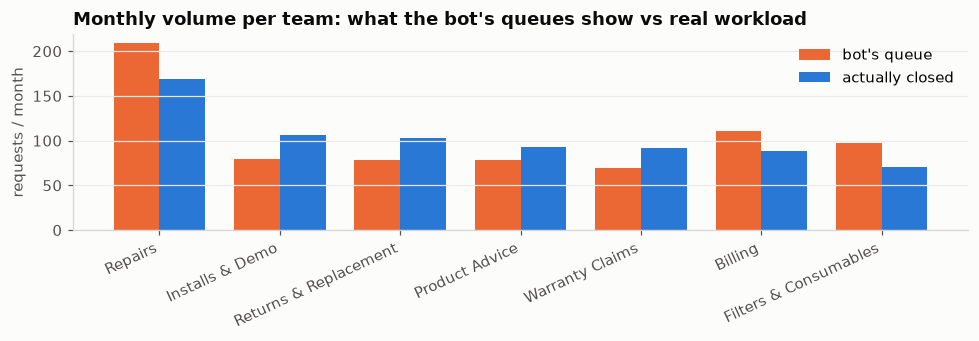

In [27]:
fig, ax = plt.subplots(figsize=(9, 3.2))
xs = np.arange(len(wl)); w = 0.38
ax.bar(xs - w/2, wl.iloc[:, 0] / 15, w, color=ORANGE, label="bot's queue")
ax.bar(xs + w/2, wl.iloc[:, 1] / 15, w, color=BLUE, label="actually closed")
ax.set_xticks(xs, wl.index, rotation=25, ha="right"); ax.set_ylabel("requests / month")
ax.set_title("Monthly volume per team: what the bot's queues show vs real workload", loc="left"); ax.legend()
plt.tight_layout(); plt.show()

**Finding.** Sizing teams from the bot's queues would over-staff Repairs and Billing and under-staff Returns, Warranty and Installs. Headcount planning should use final-team volume (or our model's predictions, which target it).

## 10 · What is the best accuracy anyone could get?

In [28]:
gg = df.groupby("shape").final_team.agg(n="size", purity=lambda s: s.value_counts(normalize=True).iloc[0])
df["shape_purity"] = df["shape"].map(gg.purity); df["shape_n"] = df["shape"].map(gg.n)
common = df.shape_n >= 15
print(f"rows in common shapes: {common.mean():.0%}")
print(f"best possible accuracy, clear requests (in-sample): {df[common & ~df.vague].shape_purity.mean():.1%}")
print(f"best possible accuracy, vague requests (in-sample): {df[common & df.vague].shape_purity.mean():.1%}")
ceiling = df[common].shape_purity.mean()
print(f"weighted ceiling: ~{ceiling:.1%}  (optimistic: in-sample, and assumes rare shapes behave like common ones)")

rows in common shapes: 93%
best possible accuracy, clear requests (in-sample): 98.1%
best possible accuracy, vague requests (in-sample): 21.7%
weighted ceiling: ~86.2%  (optimistic: in-sample, and assumes rare shapes behave like common ones)


**The 90% bar.** Against real outcomes the ceiling is ~**86%**, set by the vague 15% and label noise, not by model choice. Ritu's 90% is reachable only against the bot's own labels, which would mean copying the bot. We push back on the metric, not the ambition: the aim is fewer misroutes than the bot, priced in rupees.

## 11 · Summary: findings → decisions

| # | Finding | Evidence | Decision |
|---|---|---|---|
| 1 | `team_label` is the bot's guess (= `first_team`), right 77.2% of the time | §2 | Target = `final_team` |
| 2 | Two teams renamed 15 Jan 2026, clean cut | §3 | Merge old → new names; predict new names |
| 3 | 126 rows: first ≠ final with 0 transfers, impossible under §3 | §4 | Drop from training only (B1) |
| 4 | 351 ping-pong rows (A → B → A) | §4 | Keep; final label credible. Report the wasted transfers |
| 5 | Bot sends "I paid" requests to Billing; purifier faults to Consumables | §5 | Policy features (B2) |
| 6 | ~15% vague requests, ~22% best accuracy | §6 | Clarify-first lane in the service (C) |
| 7 | Two-intent requests follow the **last** intent ~99% | §6 | Last-clause input (B2) |
| 8 | Mojibake + accents in legacy text only | §7 | `clean_text` before any model |
| 9 | `product_family` disagrees with the text 17% of the time | §7 | Weak input + mismatch flag |
| 10 | Legacy `resolved_at` is UTC | §8 | Never a model input; +5:30 for any timing analysis |
| 11 | Bot queues mis-state team workload | §9 | Workload view for Ritu's headcount plan |
| 12 | Realistic ceiling ~86% vs final team | §10 | Push back on "90% match"; validate on a time split |